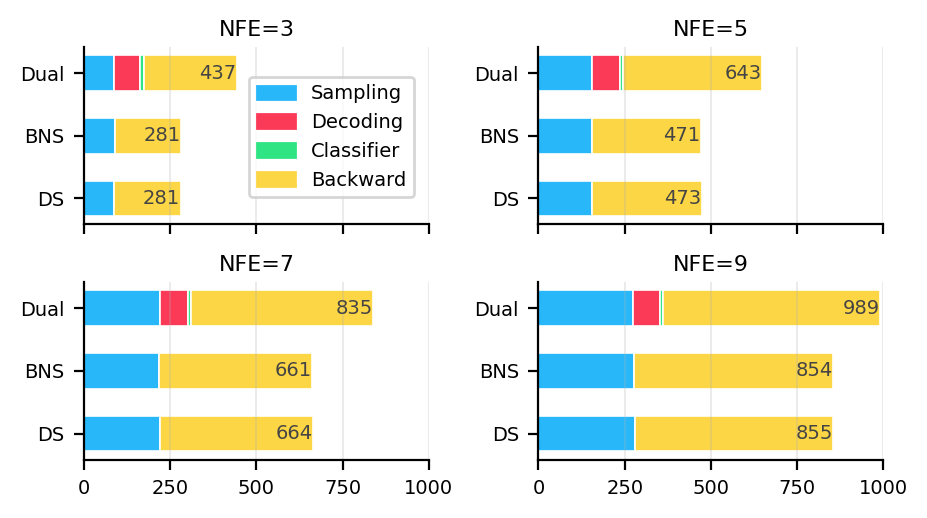

In [87]:
# Render a single 2x2 figure where the Classifier segment is drawn **only for Dual**.
# For Dual, enforce a minimum visible width of 10 ms (for visibility) but keep totals true.
# For BNS/DS, Classifier is omitted (width = 0, not drawn).

import numpy as np
import matplotlib.pyplot as plt

PALETTES = {
    "journal_printsafe": {
        "Sampling":  "#28B8FA",
        "Decoding":  "#FB3A58",
        "Classifier":"#2FE482",
        "Backward":  "#FDD645",
    },
}

data = {
    3: {"Dual":[85.85,77.86,3.76,269.92],"BNS":[88.70,0,0,192.49],"DS":[87.88,0,0,192.74]},
    5: {"Dual":[155.80,79.34,5.06,402.76],"BNS":[153.99,0,0,317.24],"DS":[154.28,0,0,319.20]},
    7: {"Dual":[220.97,79.39,6.54,527.97],"BNS":[218.91,0,0,442.33],"DS":[219.47,0,0,444.70]},
    9: {"Dual":[274.55,76.77,8.94,629.14],"BNS":[276.60,0,0,577.61],"DS":[278.49,0,0,576.50]},
}

palette = PALETTES["journal_printsafe"]
comps = ["Sampling","Decoding","Classifier","Backward"]
labels = ["Dual","BNS","DS"]

def draw_panel(ax, nfe, *, xlim=(0,1000), row_spacing=0.56, bar_height=0.32):
    base = np.arange(len(labels))[::-1]
    y = base * row_spacing

    for idx, solver in enumerate(labels):
        left_plot = 0.0
        left_true = 0.0
        for comp, w in zip(comps, data[nfe][solver]):
            # For BNS/DS, skip drawing Classifier entirely
            if comp == "Classifier" and solver != "Dual":
                left_true += 0.0
                continue
            # Only for Dual's Classifier, apply minimum visible width
            plot_w = max(w, 10.0) if (comp == "Classifier" and solver == "Dual") else w
            if plot_w > 0:
                ax.barh(y[idx], plot_w, height=bar_height, left=left_plot,
                        color=palette[comp], edgecolor="white", linewidth=0.6)
                left_plot += plot_w
            left_true += w
        tx = max(0, left_plot - 2.0)
        ax.text(tx, y[idx], f"{int(round(left_true))}", va="center", ha="right",
                fontsize=7, color="#444444", clip_on=True)

    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, alpha=0.3)
    ax.set_title(f"NFE={nfe}", fontsize=8, pad=4)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_xlim(*xlim)

plt.rcParams.update({"figure.dpi":200,"font.size":7,"axes.linewidth":0.8,"mathtext.fontset":"cm"})
fig, axes = plt.subplots(2,2, figsize=(5.0,2.6), sharex=True)
axes = axes.ravel()
for ax, nfe in zip(axes, [3,5,7,9]):
    draw_panel(ax, nfe)

for ax in axes:
    ax.set_xlim(0, 1000)
    ax.set_xticks([0,250,500,750,1000])

handles = [plt.Rectangle((0,0),1,1,color=palette[k]) for k in ["Sampling","Decoding","Classifier","Backward"]]
fig.legend(handles, ["Sampling","Decoding","Classifier","Backward"],
           loc="lower left", bbox_to_anchor=(0.24,0.60), frameon=True, fontsize=7)

plt.tight_layout(rect=[0.0,0.0,0.93,1.0])
#plt.tight_layout()
plt.show()
